In [1]:
import sys

sys.path.append("..")

In [2]:
import sys

import torch

sys.path.append("..")

In [3]:
from data.dataloader import LowLightDataModule
from model.blocks.lowlightenhancer import LowLightEnhancer
from utils.utils import show_batch, summarize_model

/home/user/anaconda3/envs/jih_icicic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_module = LowLightDataModule(
    train_dir="../data/1_train",
    valid_dir="../data/2_valid",
    bench_dir="../data/3_bench",
    infer_dir="../data/4_infer",
    image_size=512,
    batch_size=1,
    num_workers=4,
)

data_module.setup(stage="fit")

In [5]:
train_dataloader = data_module.train_dataloader()

torch.Size([1, 3, 512, 512])


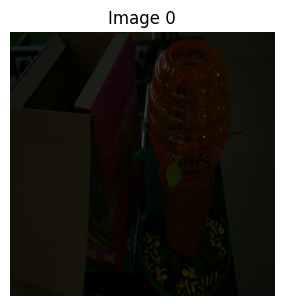

In [6]:
data = next(iter(train_dataloader))
print(data.shape)
show_batch(images=data)

In [7]:
lowlightenhancer = LowLightEnhancer(
    hidden_channels=64,
    num_resolution=4,
    dropout_ratio=0.2,
    cutoff=0.5,
    offset=0.1,
)

In [8]:
data = data.cuda()
lowlightenhancer = lowlightenhancer.cuda()

In [9]:
results = lowlightenhancer(data)

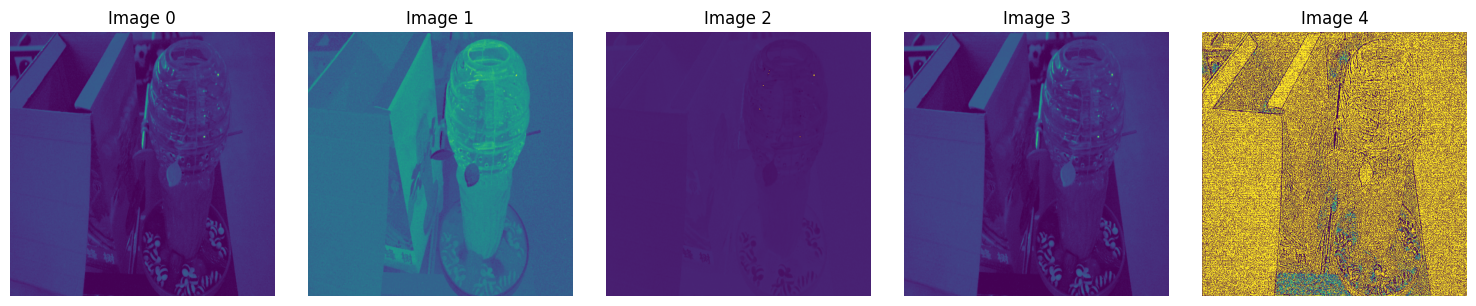

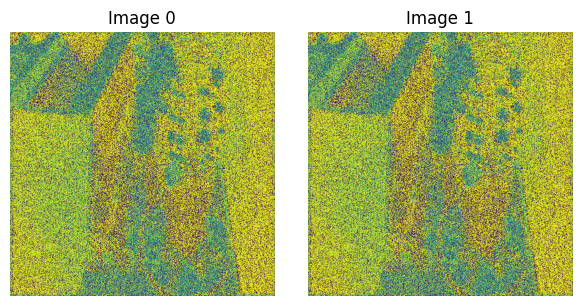

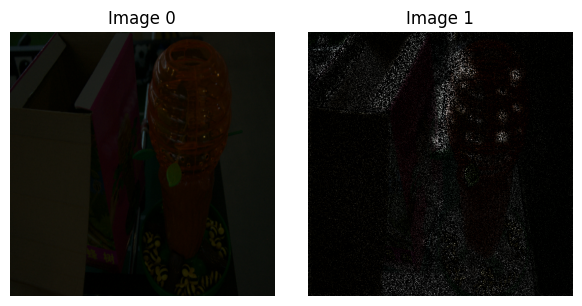

In [10]:
show_batch(
    images=torch.cat(
        tensors=[
            results["low_luminance"],
            results["low_chroma_red"],
            results["low_chroma_blue"],
            results["low_illuminance"],
            results["low_reflectance"],
        ],
        dim=0,
    )
)
show_batch(
    images=torch.cat(
        tensors=[
            results["enh_illuminance"],
            results["enh_luminance"],
        ],
        dim=0,
    )
)
show_batch(
    images=torch.cat(
        tensors=[
            results["low_rgb"],
            results["enh_rgb"],
        ],
        dim=0,
    )
)

In [11]:
summarize_model(model=lowlightenhancer, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                        Output Shape              Param #
LowLightEnhancer                              [1, 3, 256, 256]          --
├─ImageDecomposition: 1-1                     [1, 1, 256, 256]          --
│    └─RGB2YCrCbBlock: 2-1                    [1, 1, 256, 256]          --
│    └─HomomorphicSeparationBlock: 2-2        [1, 1, 256, 256]          --
├─IlluminationEnhancer: 1-2                   [1, 1, 256, 256]          --
│    └─Conv2d: 2-3                            [1, 64, 256, 256]         640
│    └─ModuleList: 2-4                        --                        --
│    │    └─DoubleConv: 3-1                   [1, 64, 256, 256]         147,968
│    │    └─Downsampling: 3-2                 [1, 128, 128, 128]        32,768
│    │    └─DoubleConv: 3-3                   [1, 128, 128, 128]        590,848
│    │    └─Downsampling: 3-4                 [1, 256, 64, 64]          131,072
│    │    └─DoubleConv: 3-5                   [1, 256, 64, 64]          2,3